<a href="https://colab.research.google.com/github/maulidyaafriani/PCVK_Genap_2026/blob/main/Week5_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Maulidya Afriani'
NIM  = '244107020059'

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Maulidya Afriani
NIM    : 244107020059 | N = 59
bins   : 64
clip   : 3.0
tile   : 5
L      : 8
WAKTU  : 2026-09-27 09:38:05 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 0ed12c742a44bfd9


In [16]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

CONTOH = '/content/drive/MyDrive/PCVK/Images/244107020059'
BASE   = '/content/drive/MyDrive/PCVK/Images/244107020059'

Mounted at /content/drive


In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

In [17]:
import os
print(os.path.exists(CONTOH + '/lena.jpg'))
print(os.listdir(CONTOH))

True
['lena.jpg', 'lena_lc.jpg', 'KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg', 'OBJ1.jpg', 'galaxy.jpg', 'noises-image.zip', 'noises', 'NIGHT1.jpg']


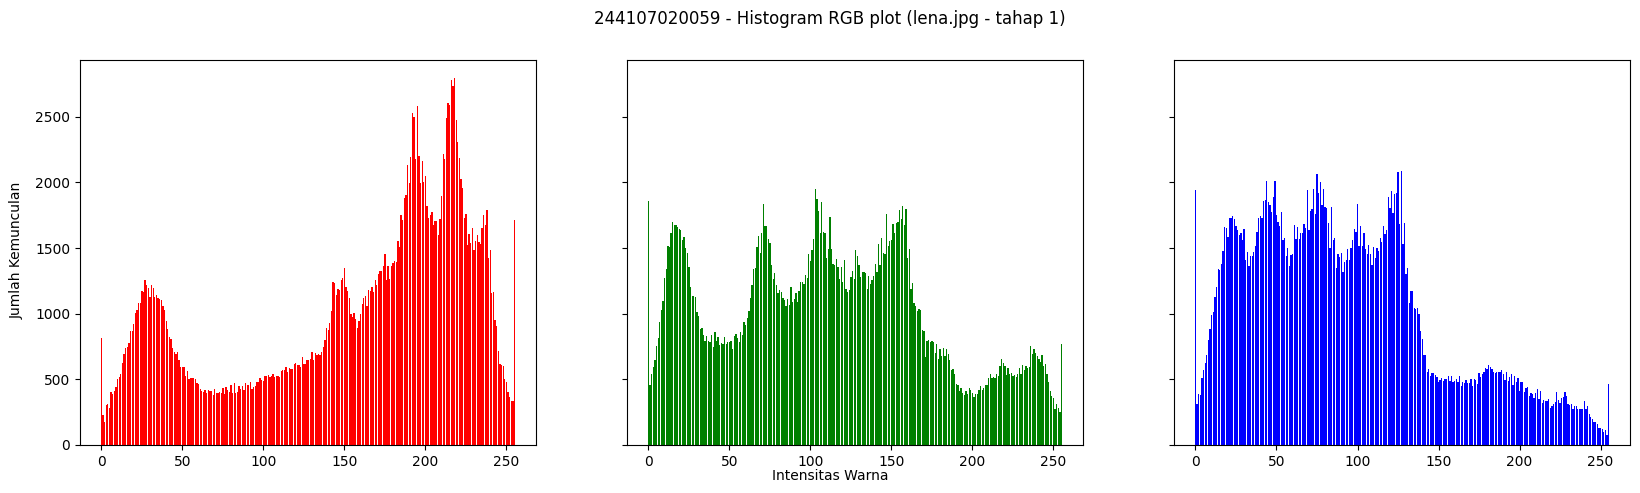

In [18]:
img = cv.imread(CONTOH + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (lena.jpg - tahap 1)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

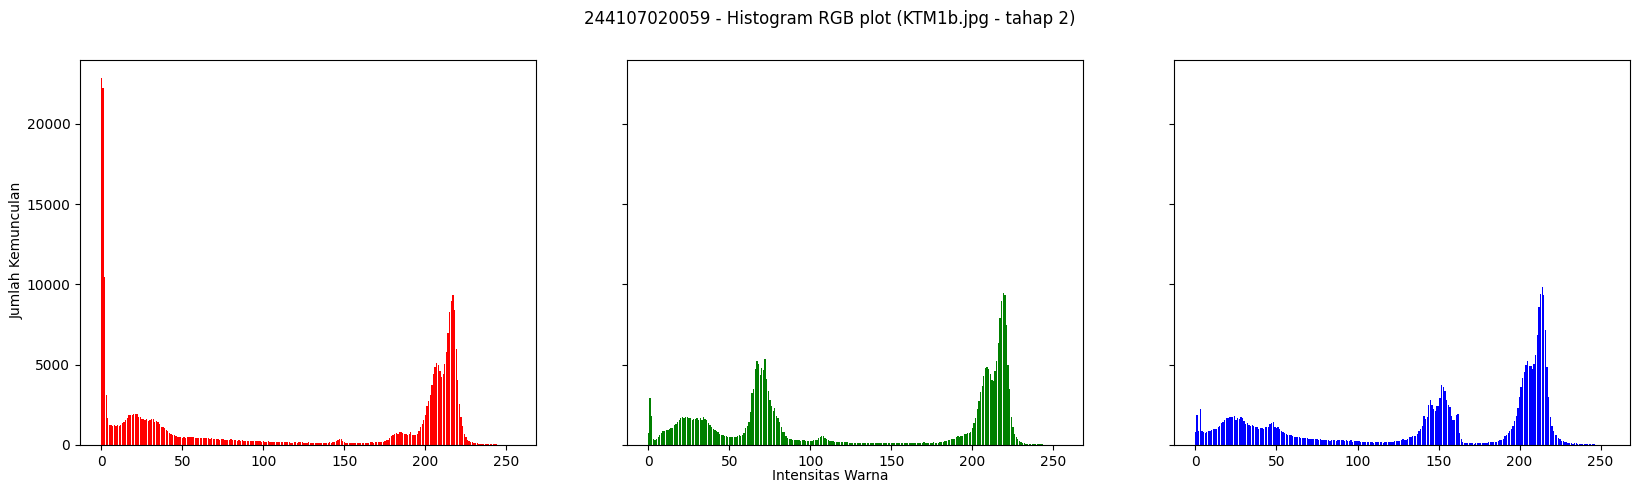

In [19]:
img = cv.imread(BASE + '/KTM1b.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (KTM1b.jpg - tahap 2)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

In [20]:
def histogram_manual(channel):
    h = np.zeros(256, dtype=np.int64)
    for y in range(channel.shape[0]):
        for x in range(channel.shape[1]):
            h[channel[y, x]] += 1
    return h

def bandingkan_histogram(nama_file, label):
    img_bgr = cv.imread(nama_file)
    gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    h_manual = histogram_manual(gray)
    h_numpy, _ = np.histogram(gray, bins=256, range=(0, 256))
    h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

    selisih_np_manual = np.max(np.abs(h_manual - h_numpy))
    selisih_cv_manual = np.max(np.abs(h_manual - h_cv))
    selisih_np_cv      = np.max(np.abs(h_numpy - h_cv))

    print(f'--- {label} ---')
    print('Selisih maksimum manual vs numpy.histogram :', selisih_np_manual)
    print('Selisih maksimum manual vs cv.calcHist      :', selisih_cv_manual)
    print('Selisih maksimum numpy vs cv.calcHist       :', selisih_np_cv)
    print()

bandingkan_histogram(CONTOH + '/lena.jpg', 'lena.jpg')
bandingkan_histogram(BASE + '/KTM1b.jpg', 'KTM1b.jpg')

--- lena.jpg ---
Selisih maksimum manual vs numpy.histogram : 0
Selisih maksimum manual vs cv.calcHist      : 0
Selisih maksimum numpy vs cv.calcHist       : 0

--- KTM1b.jpg ---
Selisih maksimum manual vs numpy.histogram : 0
Selisih maksimum manual vs cv.calcHist      : 0
Selisih maksimum numpy vs cv.calcHist       : 0



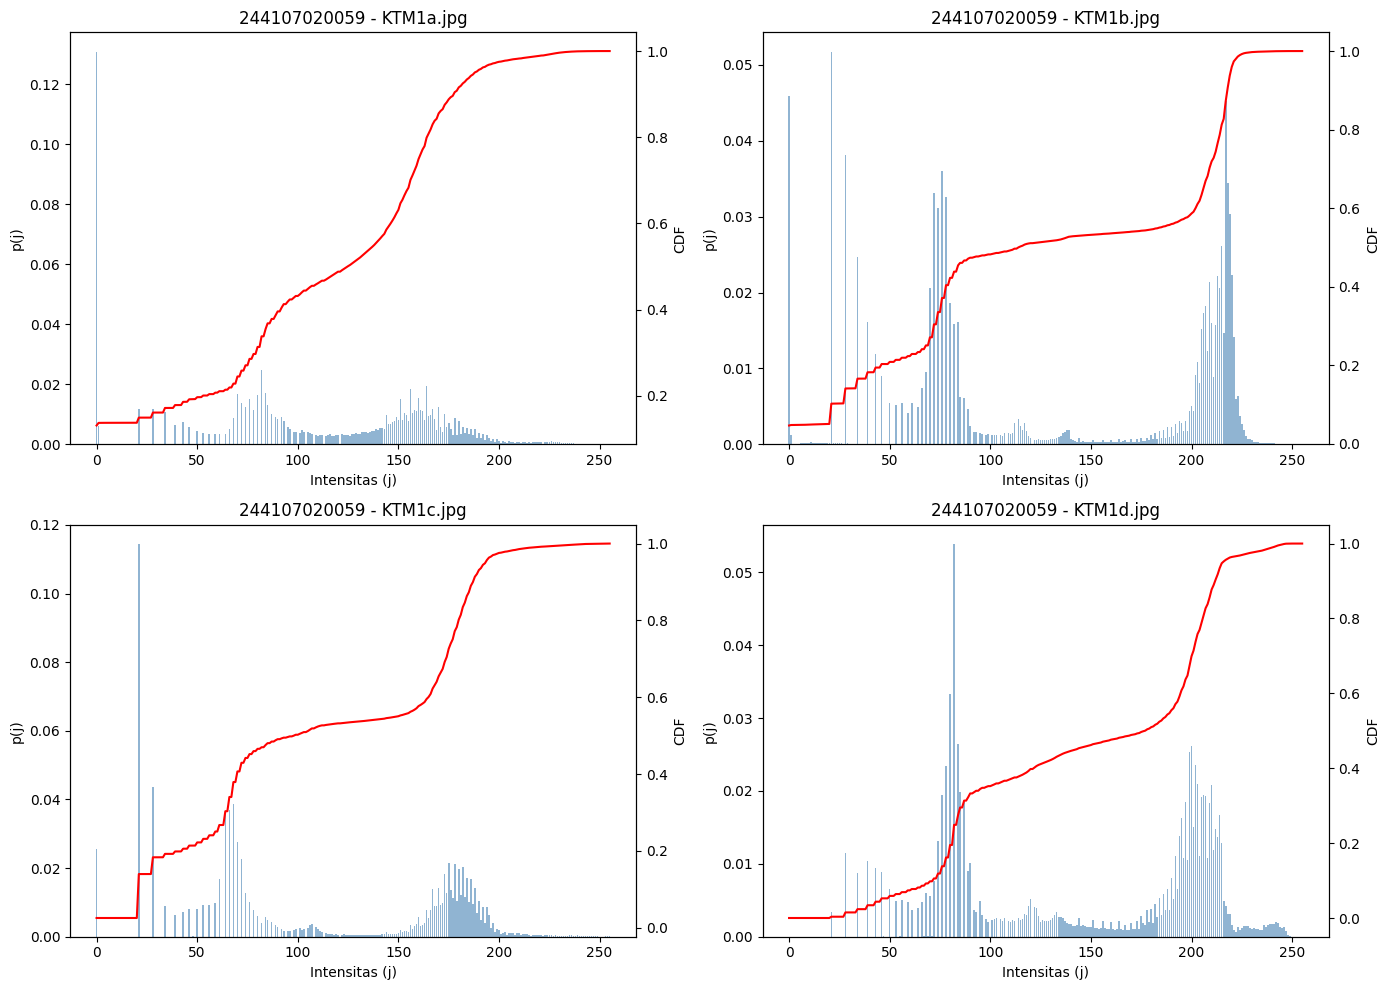

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

nama_file = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']

for i, nf in enumerate(nama_file):
    gray = cv.imread(BASE + '/' + nf, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(gray)
    p = h / gray.size
    cdf = np.cumsum(p)

    ax2 = axs[i].twinx()
    axs[i].bar(np.arange(256), p, color='steelblue', alpha=0.6, label='p(j)')
    ax2.plot(np.arange(256), cdf, color='red', label='CDF')
    axs[i].set_title(NIM + ' - ' + nf)
    axs[i].set_xlabel('Intensitas (j)')
    axs[i].set_ylabel('p(j)')
    ax2.set_ylabel('CDF')

plt.tight_layout()
plt.show()

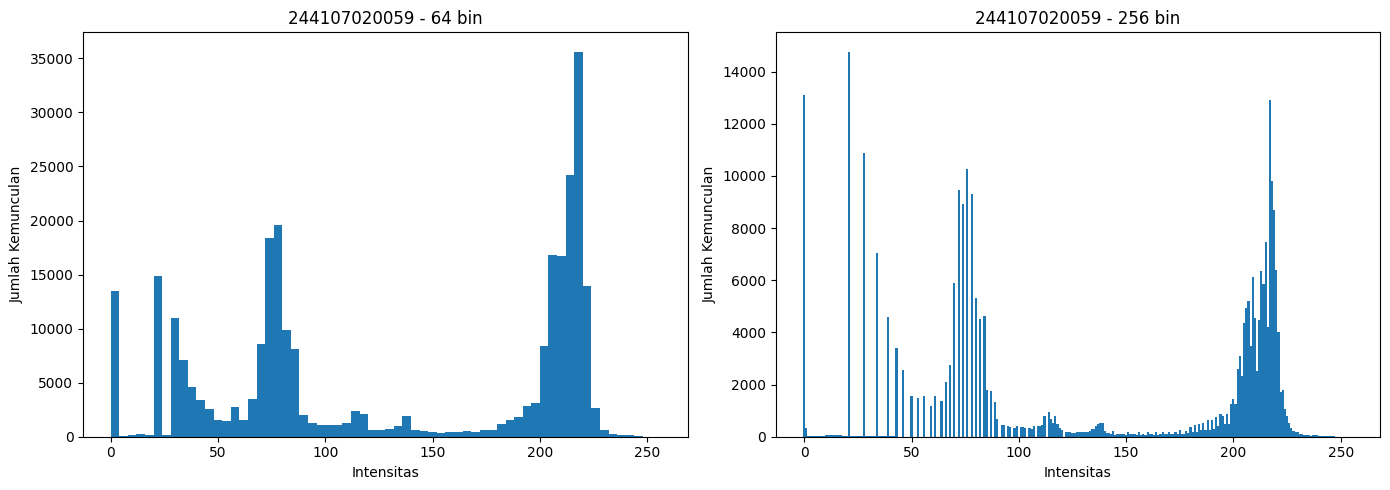

In [22]:
gray = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

h_sedikit_bin, edges_sedikit = np.histogram(gray, bins=PARAM['bins'], range=(0, 256))
h_256, edges_256 = np.histogram(gray, bins=256, range=(0, 256))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].bar(edges_sedikit[:-1], h_sedikit_bin, width=np.diff(edges_sedikit), align='edge')
axs[0].set_title(NIM + f" - {PARAM['bins']} bin")
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Kemunculan')

axs[1].bar(edges_256[:-1], h_256, width=1)
axs[1].set_title(NIM + ' - 256 bin')
axs[1].set_xlabel('Intensitas')
axs[1].set_ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

PERCOBAAN E-2

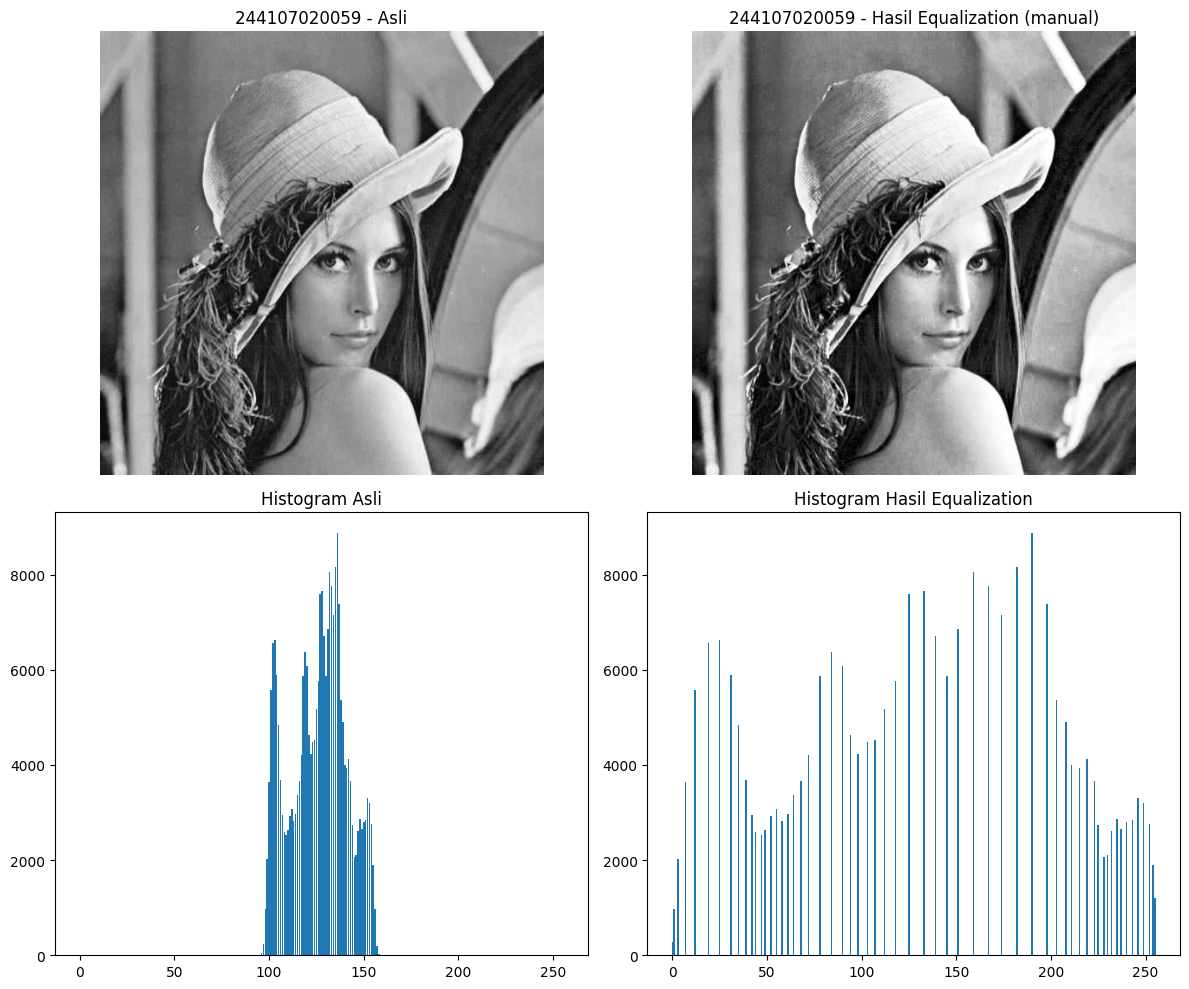

In [23]:
def histogram_equalization_manual(gray):
    h = histogram_manual(gray)
    MN = gray.size
    p = h / MN
    cdf = np.cumsum(p)
    L = 256
    transform = np.round(cdf * (L - 1)).astype(np.uint8)
    hasil = transform[gray]
    return hasil, transform

gray = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
hasil_manual, transform = histogram_equalization_manual(gray)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0,0].imshow(gray, cmap='gray')
axs[0,0].set_title(NIM + ' - Asli')
axs[0,0].axis('off')

axs[0,1].imshow(hasil_manual, cmap='gray')
axs[0,1].set_title(NIM + ' - Hasil Equalization (manual)')
axs[0,1].axis('off')

axs[1,0].bar(np.arange(256), histogram_manual(gray))
axs[1,0].set_title('Histogram Asli')

axs[1,1].bar(np.arange(256), histogram_manual(hasil_manual))
axs[1,1].set_title('Histogram Hasil Equalization')

plt.tight_layout()
plt.show()

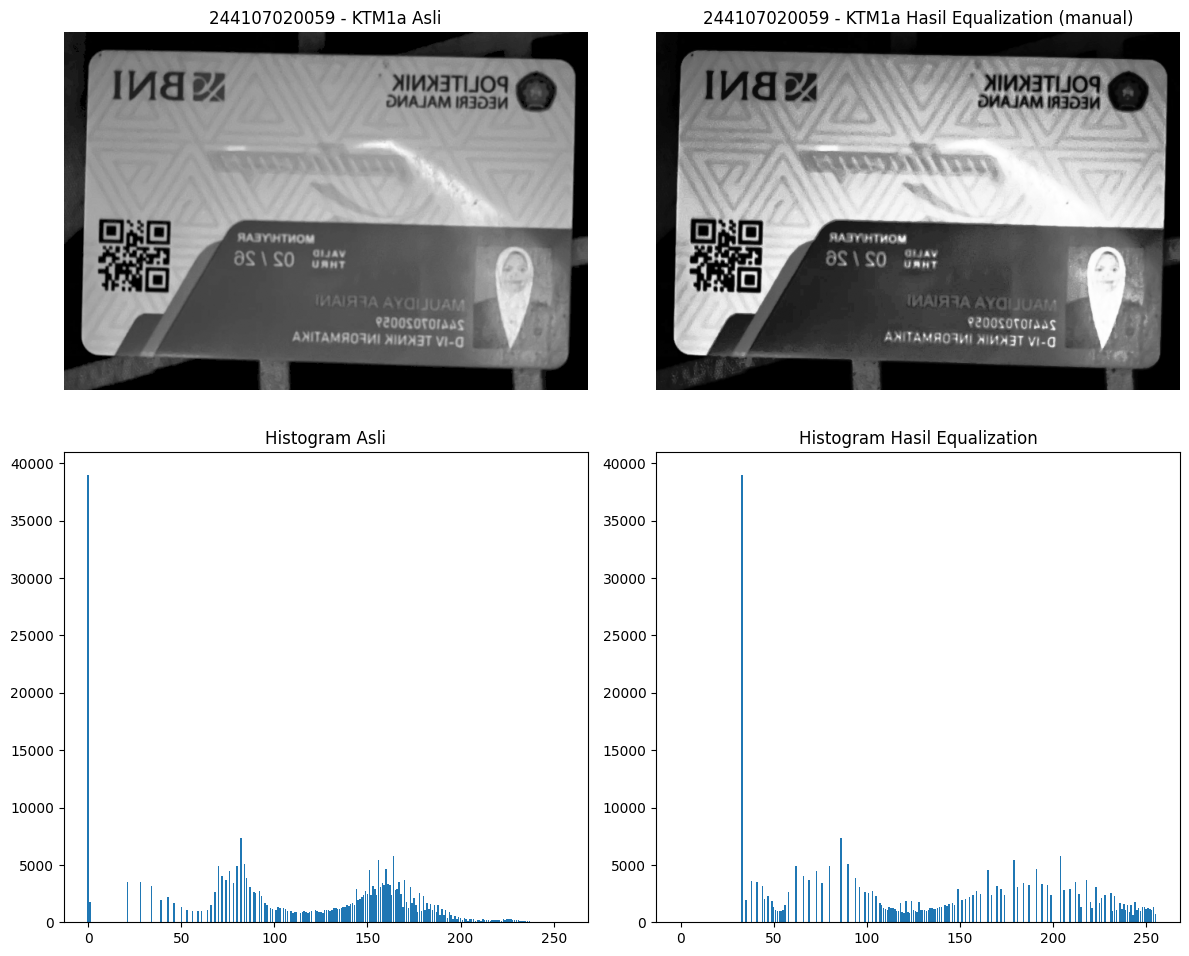

In [24]:
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
hasil_manual, transform = histogram_equalization_manual(gray)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0,0].imshow(gray, cmap='gray')
axs[0,0].set_title(NIM + ' - KTM1a Asli')
axs[0,0].axis('off')

axs[0,1].imshow(hasil_manual, cmap='gray')
axs[0,1].set_title(NIM + ' - KTM1a Hasil Equalization (manual)')
axs[0,1].axis('off')

axs[1,0].bar(np.arange(256), histogram_manual(gray))
axs[1,0].set_title('Histogram Asli')

axs[1,1].bar(np.arange(256), histogram_manual(hasil_manual))
axs[1,1].set_title('Histogram Hasil Equalization')

plt.tight_layout()
plt.show()

In [25]:
def bandingkan_equalize(nama_file, label):
    gray = cv.imread(nama_file, cv.IMREAD_GRAYSCALE)
    hasil_manual, _ = histogram_equalization_manual(gray)
    hasil_cv = cv.equalizeHist(gray)

    selisih = np.max(np.abs(hasil_manual.astype(int) - hasil_cv.astype(int)))
    print(f'--- {label} ---')
    print('Selisih maksimum manual vs cv.equalizeHist:', selisih)
    print()
    return hasil_manual, hasil_cv

hm1, hc1 = bandingkan_equalize(CONTOH + '/lena_lc.jpg', 'lena_lc.jpg')
hm2, hc2 = bandingkan_equalize(BASE + '/KTM1a.jpg', 'KTM1a.jpg')

--- lena_lc.jpg ---
Selisih maksimum manual vs cv.equalizeHist: 0

--- KTM1a.jpg ---
Selisih maksimum manual vs cv.equalizeHist: 33



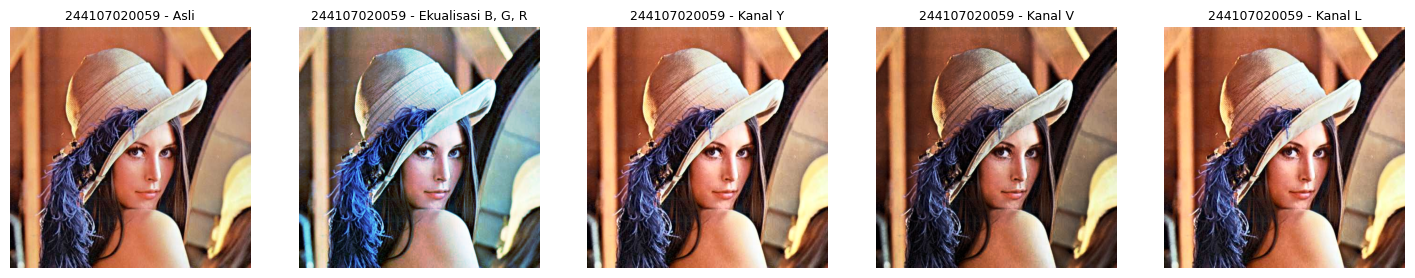

In [26]:
berkas = CONTOH + '/lena.jpg'   # tahap 2 nanti ganti ke: BASE + '/KTM1d.jpg'
bgr = cv.imread(berkas)

# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

In [27]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7


**pertanyaan analisis**

1. Cara paling besar pergeseran Hue-nya: Ekualisasi B,G,R terpisah — 53.03°, jauh banget dibanding yang lain. Soalnya tiap kanal warna diubah sendiri-sendiri, jadi rasio antar warnanya berantakan dan bikin corak warna berubah.

2. Kenapa kanal Y/V/L tetap geser dikit (nggak 0 persis): Karena proses bolak-balik convert ruang warna (RGB → YCrCb/HSV/LAB → RGB) itu melibatkan pembulatan angka desimal ke integer beberapa kali. Walau cuma kecerahan yang diubah, sisa-sisa pembulatan kecil ini bikin Hue geser dikit, bukan karena salah logika.

3. Mana yang paling cocok buat KTM kamu — Kanal Y. Alasannya:

  Pergeserannya paling kecil (cuma 0.40°), jadi warna asli KTM paling terjaga
  Kecerahannya naik wajar (122.2 → 127.9), sesuai tujuan bikin foto ruangan gelap jadi lebih terang
  Kanal V malah kecerahannya turun (122.2 → 100.6), ini kebalikan dari yang kita mau
  Kanal L pergeserannya lumayan besar (1.65°) tapi kecerahannya nyaris nggak naik (122.7), jadi kurang berguna juga

Pergeseran Hue (CLAHE): 2.056884765625
Rerata kecerahan (CLAHE): 125.19248962402344
Pergeseran Hue (equalizeHist biasa, kanal L): 1.6529464721679688
Rerata kecerahan (equalizeHist biasa, kanal L): 122.72317886352539


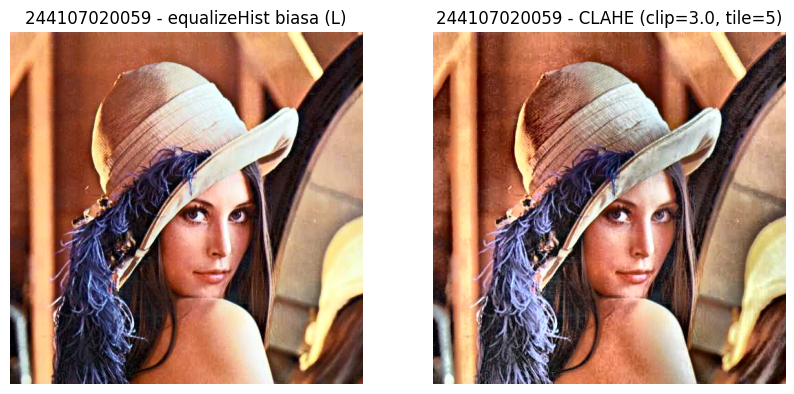

In [28]:
# Contoh: pakai kanal L (LAB) + CLAHE
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
l_clahe = clahe.apply(l)
he_l_clahe = cv.cvtColor(cv.merge([l_clahe, a, b]), cv.COLOR_LAB2BGR)

print('Pergeseran Hue (CLAHE):', geser_hue(bgr, he_l_clahe) * 2)
print('Rerata kecerahan (CLAHE):', cv.cvtColor(he_l_clahe, cv.COLOR_BGR2GRAY).mean())
print('Pergeseran Hue (equalizeHist biasa, kanal L):', geser_hue(bgr, he_l) * 2)
print('Rerata kecerahan (equalizeHist biasa, kanal L):', cv.cvtColor(he_l, cv.COLOR_BGR2GRAY).mean())

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(he_l, cv.COLOR_BGR2RGB))
axs[0].set_title(NIM + ' - equalizeHist biasa (L)')
axs[0].axis('off')
axs[1].imshow(cv.cvtColor(he_l_clahe, cv.COLOR_BGR2RGB))
axs[1].set_title(NIM + f" - CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})")
axs[1].axis('off')
plt.show()

**PERTANYAAN PRAKTIKUM E2**

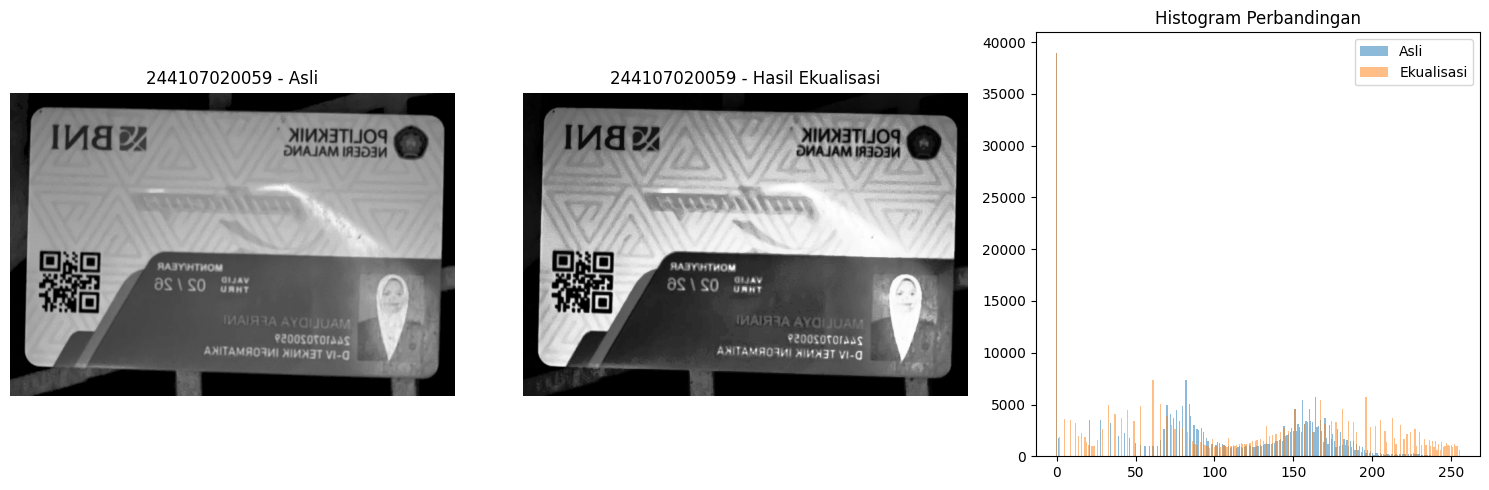

MSE  : 688.2540094126014
PSNR : 19.753316108196923 dB


In [29]:
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
hasil_manual, _ = histogram_equalization_manual(gray)
hasil_cv = cv.equalizeHist(gray)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(gray, cmap='gray')
axs[0].set_title(NIM + ' - Asli')
axs[0].axis('off')

axs[1].imshow(hasil_cv, cmap='gray')
axs[1].set_title(NIM + ' - Hasil Ekualisasi')
axs[1].axis('off')

axs[2].bar(np.arange(256), histogram_manual(gray), alpha=0.5, label='Asli')
axs[2].bar(np.arange(256), histogram_manual(hasil_cv), alpha=0.5, label='Ekualisasi')
axs[2].legend()
axs[2].set_title('Histogram Perbandingan')

plt.tight_layout()
plt.show()

# Hitung PSNR
mse = np.mean((gray.astype(float) - hasil_cv.astype(float)) ** 2)
psnr = 10 * np.log10((255 ** 2) / mse) if mse != 0 else float('inf')
print('MSE  :', mse)
print('PSNR :', psnr, 'dB')

Jawaban analisis PSNR: PSNR mengukur seberapa mirip dua citra secara piksel per piksel — nilainya turun karena ekualisasi sengaja mengubah nilai piksel secara signifikan (itu tujuannya, biar kontras lebih baik), sehingga secara matematis dianggap "beda jauh" dari citra asli meski secara visual citra hasil justru lebih mudah dibaca mata manusia. Kesimpulan: PSNR tidak layak dipakai untuk menilai keterbacaan citra hasil enhancement seperti histogram equalization, karena PSNR mengasumsikan citra referensi (asli) adalah "yang benar", padahal di sini justru citra yang diubah itu yang lebih baik untuk dilihat. PSNR lebih cocok dipakai untuk menilai kualitas kompresi atau noise, bukan untuk menilai citra yang sengaja diperbaiki kontrasnya.

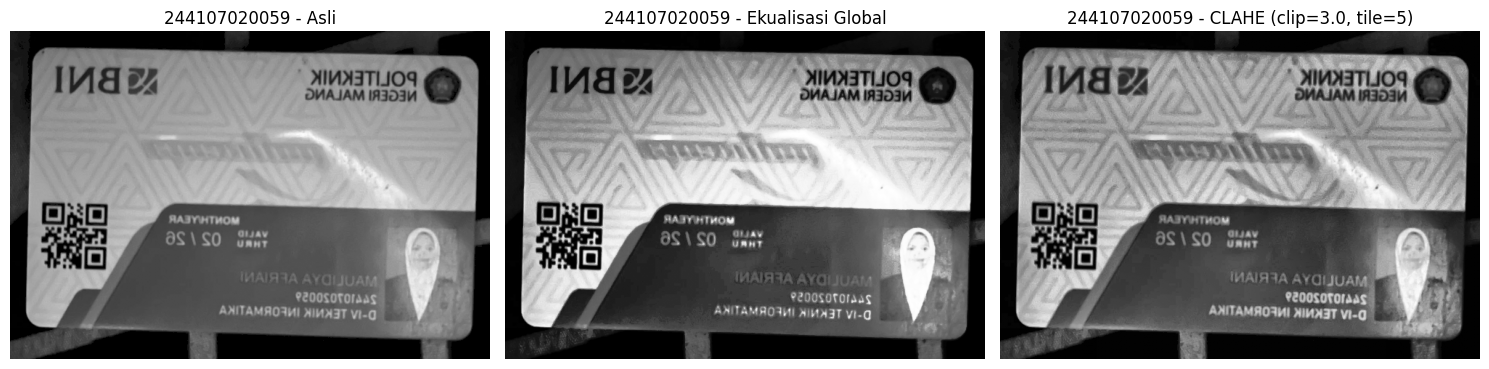

In [30]:
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
hasil_global = cv.equalizeHist(gray)

clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe = clahe.apply(gray)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(gray, cmap='gray')
axs[0].set_title(NIM + ' - Asli')
axs[0].axis('off')

axs[1].imshow(hasil_global, cmap='gray')
axs[1].set_title(NIM + ' - Ekualisasi Global')
axs[1].axis('off')

axs[2].imshow(hasil_clahe, cmap='gray')
axs[2].set_title(NIM + f" - CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})")
axs[2].axis('off')

plt.tight_layout()
plt.show()

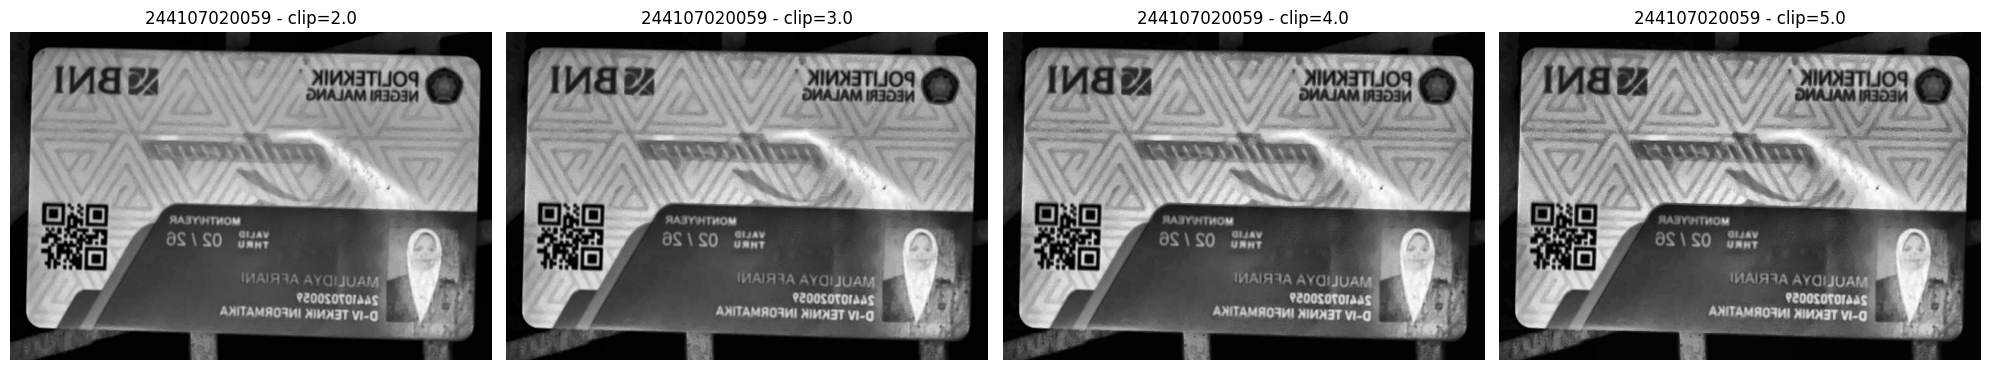

In [31]:
nilai_clip_uji = [PARAM['clip'] - 1.0, PARAM['clip'], PARAM['clip'] + 1.0, PARAM['clip'] + 2.0]
nilai_clip_uji = [c for c in nilai_clip_uji if c > 0]  # buang nilai negatif kalau ada

fig, axs = plt.subplots(1, len(nilai_clip_uji), figsize=(5*len(nilai_clip_uji), 5))
for i, clip_val in enumerate(nilai_clip_uji):
    clahe_uji = cv.createCLAHE(clipLimit=clip_val, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe_uji.apply(gray)
    axs[i].imshow(hasil, cmap='gray')
    axs[i].set_title(NIM + f' - clip={clip_val}')
    axs[i].axis('off')
plt.tight_layout()
plt.show()

a. CLAHE vs Ekualisasi Global

CLAHE lebih terbaca. Soalnya CLAHE bagi gambar jadi blok-blok kecil terus diekualisasi satu-satu, jadi teks NIM/nama yang tadinya gelap bisa keangkat kontrasnya walau area sekitarnya udah cukup terang. Kalau ekualisasi global kan cuma satu perhitungan buat seluruh gambar, jadi kurang maksimal ngangkat detail kecil kayak teks.

b. Bandingin clip 2.0, 3.0, 4.0, 5.0 — mana yang paling bagus?

clip=2.0: masih agak lembut, teks kebaca tapi belum tajem banget
clip=3.0: udah pas — teks & pola kartu jelas, belum keliatan berisik
clip=4.0: mulai keliatan bintik-bintik noise di bagian background yang polos
clip=5.0: noise-nya makin keliatan jelas, terutama di area gelap yang rata

Nilai terbaik: clip=3.0 — udah cukup jelas buat baca teks, tapi belum keganggu noise. Naik ke 4.0 atau 5.0 malah nambah noise doang, keterbacaan teksnya nggak nambah banyak.

Bagian yang paling keliatan noise-nya: background pola segitiga sama area polos di sekitar foto/QR code — karena di situ variasi warnanya kecil banget, jadi pas dipaksa nyebar histogramnya, noise kecil dari kamera ikut kebesarin jadi bintik-bintik yang lebih keliatan.

**E-3: Tugas Praktikum Dithering**

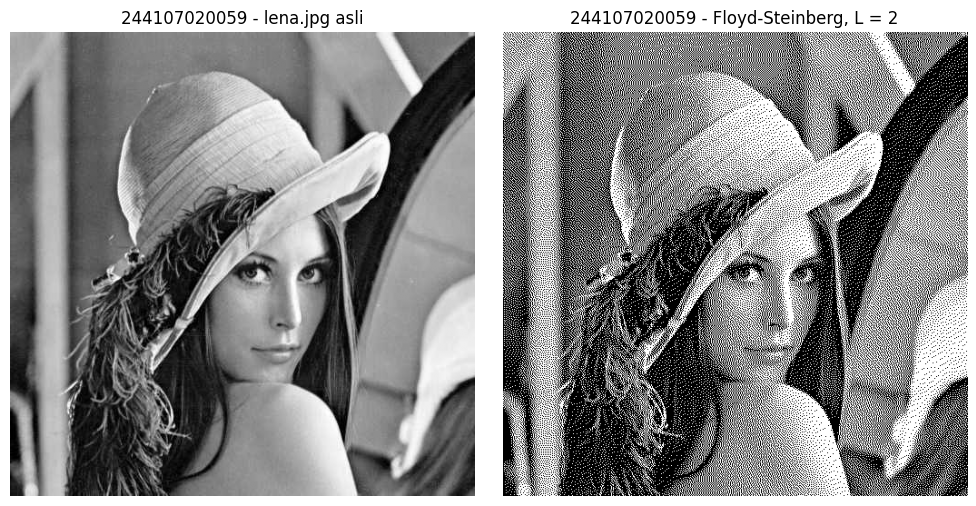

In [32]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                 img[y,   x+1] += error * 7 / 16
            if x > 0 and y+1 < H:         img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                 img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y+1 < H:     img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

# ===== TAHAP 1: lena.jpg, L=2 =====
gray = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
hasil = floyd_steinberg(gray, L=2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(gray, cmap='gray')
axs[0].set_title(NIM + ' - lena.jpg asli')
axs[0].axis('off')
axs[1].imshow(hasil, cmap='gray')
axs[1].set_title(NIM + ' - Floyd-Steinberg, L = 2')
axs[1].axis('off')
plt.tight_layout()
plt.show()

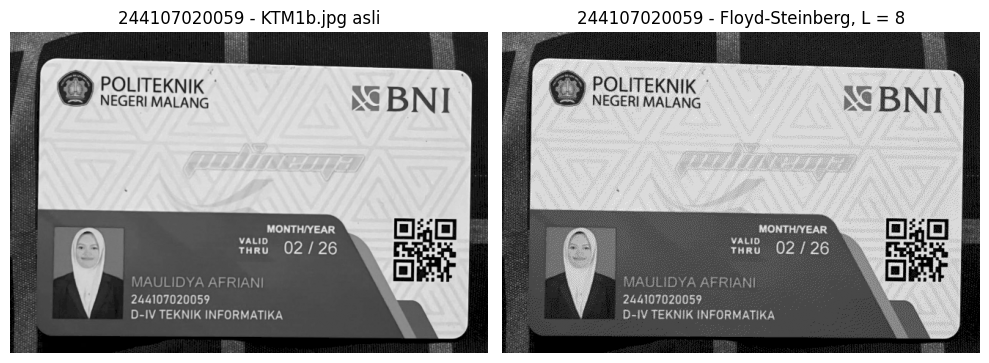

In [33]:
# ===== TAHAP 2: KTM1b.jpg dengan PARAM['L'] =====
gray = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
hasil = floyd_steinberg(gray, L=PARAM['L'])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(gray, cmap='gray')
axs[0].set_title(NIM + ' - KTM1b.jpg asli')
axs[0].axis('off')
axs[1].imshow(hasil, cmap='gray')
axs[1].set_title(NIM + f" - Floyd-Steinberg, L = {PARAM['L']}")
axs[1].axis('off')
plt.tight_layout()
plt.show()

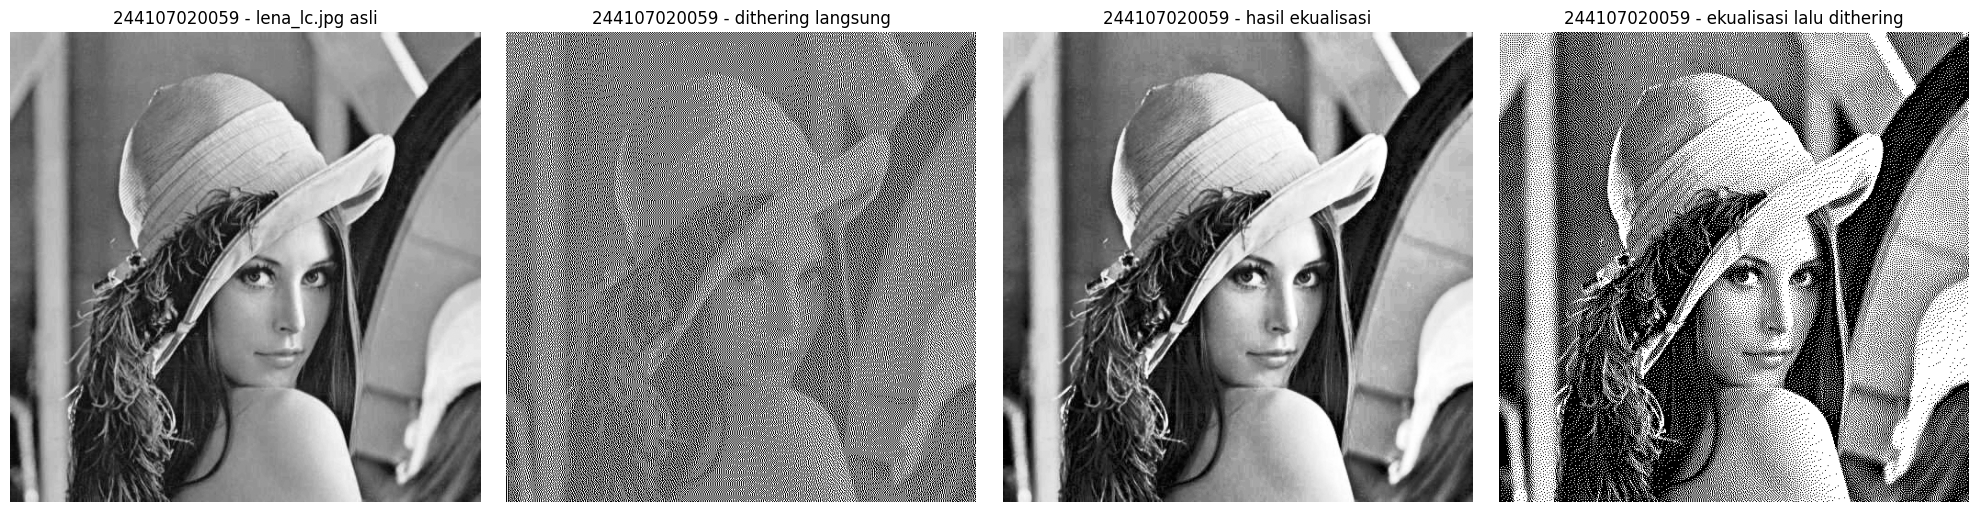

In [34]:
# ===== TAHAP 1: lena_lc.jpg =====
gray_lc = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)

dithering_langsung = floyd_steinberg(gray_lc, L=2)

hasil_ekualisasi = cv.equalizeHist(gray_lc)
ekualisasi_lalu_dithering = floyd_steinberg(hasil_ekualisasi, L=2)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(gray_lc, cmap='gray')
axs[0].set_title(NIM + ' - lena_lc.jpg asli')
axs[0].axis('off')

axs[1].imshow(dithering_langsung, cmap='gray')
axs[1].set_title(NIM + ' - dithering langsung')
axs[1].axis('off')

axs[2].imshow(hasil_ekualisasi, cmap='gray')
axs[2].set_title(NIM + ' - hasil ekualisasi')
axs[2].axis('off')

axs[3].imshow(ekualisasi_lalu_dithering, cmap='gray')
axs[3].set_title(NIM + ' - ekualisasi lalu dithering')
axs[3].axis('off')

plt.tight_layout()
plt.show()

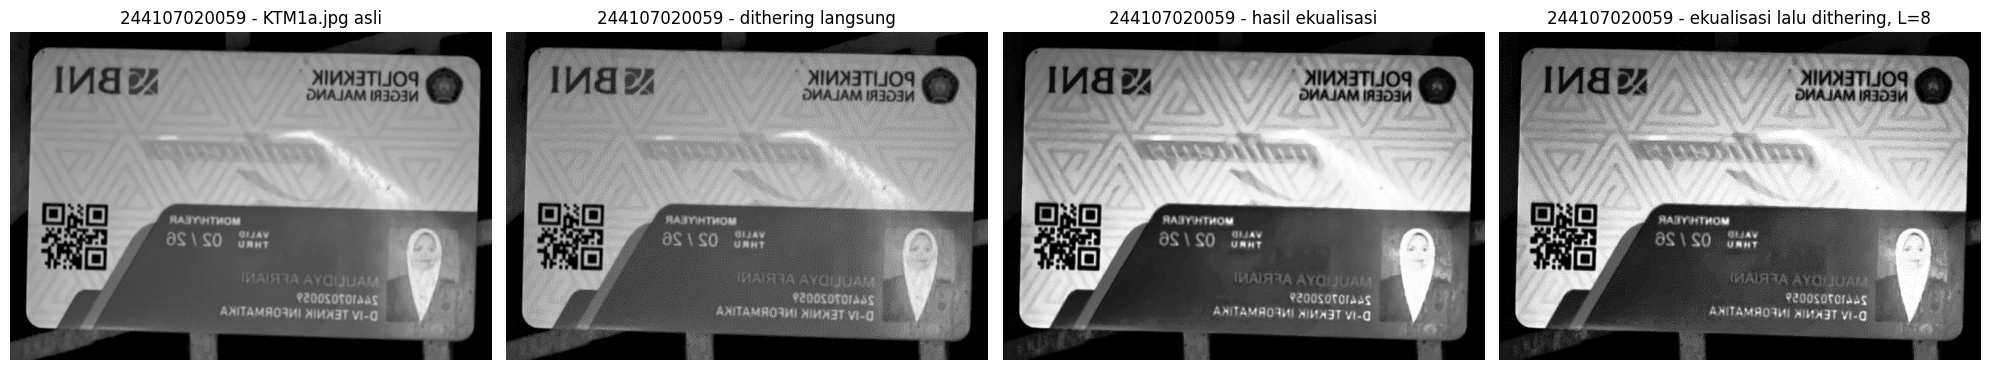

In [35]:
# ===== TAHAP 2: KTM1a.jpg =====
gray_ktm = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

dithering_langsung_ktm = floyd_steinberg(gray_ktm, L=PARAM['L'])

hasil_ekualisasi_ktm = cv.equalizeHist(gray_ktm)
ekualisasi_lalu_dithering_ktm = floyd_steinberg(hasil_ekualisasi_ktm, L=PARAM['L'])

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(gray_ktm, cmap='gray')
axs[0].set_title(NIM + ' - KTM1a.jpg asli')
axs[0].axis('off')

axs[1].imshow(dithering_langsung_ktm, cmap='gray')
axs[1].set_title(NIM + ' - dithering langsung')
axs[1].axis('off')

axs[2].imshow(hasil_ekualisasi_ktm, cmap='gray')
axs[2].set_title(NIM + ' - hasil ekualisasi')
axs[2].axis('off')

axs[3].imshow(ekualisasi_lalu_dithering_ktm, cmap='gray')
axs[3].set_title(NIM + f" - ekualisasi lalu dithering, L={PARAM['L']}")
axs[3].axis('off')

plt.tight_layout()
plt.show()

**ANALISIS HASIL **

**Image 1 (lena.jpg, L=2):**
Hasilnya udah bener, sama kayak contoh modul. Banyak titik hitam-putih karena cuma 2 level warna, tapi bentuk wajah & topi masih jelas.

**Image 2 (KTM1b.jpg, L=8):** Karena levelnya 8, hasilnya jauh lebih halus, hampir mirip aslinya. Makin banyak level warna, makin dikit titik-titik dithering yang keliatan.

**Image 3 (lena_lc.jpg)**: Dithering langsung keliatan lebih flat/kurang detail, sedangkan ekualisasi dulu baru dithering hasilnya lebih tajam dan wajahnya lebih kebaca.

**Image 4 (KTM1a.jpg, L=8):**
Karena L=8 cukup tinggi, efek ditheringnya jadi halus, jadi keempat gambar keliatan mirip-mirip sekilas.

Urutan paling kebaca teksnya: ekualisasi dulu baru dithering

Soalnya KTM1a difoto di ruangan gelap, kontrasnya rendah, teks nama/NIM agak nyatu sama background. Kalau langsung dithering tanpa ekualisasi, kontras yang emang udah rendah ya tetep rendah, teksnya kurang nonjol. Tapi kalau diekualisasi dulu (kontrasnya dilebarin), baru di-dithering, teksnya jadi lebih keangkat dan lebih gampang dibedain dari background.

Bedanya emang nggak terlalu kentara karena L=8 udah tinggi (efek dithering minim). Tapi kalau di-zoom bagian teks nama/NIM, versi ekualisasi+dithering harusnya tetep sedikit lebih jelas dibanding dithering langsung.